# Chapter 7 notebook — YOLO object detection on the edge

Walks through `docs/10_object_detection_edge.md`:
1. Run YOLOv8n on a single image, sweep `conf` thresholds.
2. Compare imgsz=320 vs 416 vs 640 (speed vs detail).
3. Loop through a short video and measure end-to-end FPS.
4. Export to ONNX and confirm it loads.

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

WEIGHTS = Path('../projects/project_02_yolo_realtime_camera/yolov8n.pt')
if not WEIGHTS.exists():
    print('weights not local; ultralytics will download yolov8n.pt on first use')
model = YOLO('yolov8n.pt' if not WEIGHTS.exists() else WEIGHTS.as_posix())
print('model loaded; class count:', len(model.names))

model loaded; class count: 80


## 1. Single-image detection on the sample image

(The sample is a synthetic cat-shape we drew in Chapter 3 — YOLO won't find a 'cat' class but it may report 'kite' or similar based on the shape.)

In [2]:
img_path = '../datasets/sample.jpg'
for conf in [0.1, 0.25, 0.5]:
    r = model.predict(source=img_path, imgsz=640, conf=conf, iou=0.45, verbose=False)[0]
    print(f'conf={conf:.2f}: {len(r.boxes)} detections')
    for b in r.boxes:
        cls = r.names[int(b.cls.item())]
        score = float(b.conf.item())
        xyxy = b.xyxy.tolist()[0]
        print(f'   {cls:<15s} score={score:.2f}  box={[round(v,1) for v in xyxy]}')

conf=0.10: 1 detections
   kite            score=0.86  box=[178.9, 58.7, 463.4, 384.1]
conf=0.25: 1 detections
   kite            score=0.86  box=[178.9, 58.7, 463.4, 384.1]
conf=0.50: 1 detections
   kite            score=0.86  box=[178.9, 58.7, 463.4, 384.1]


/home/bangbc/miniforge3/envs/aicourse/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


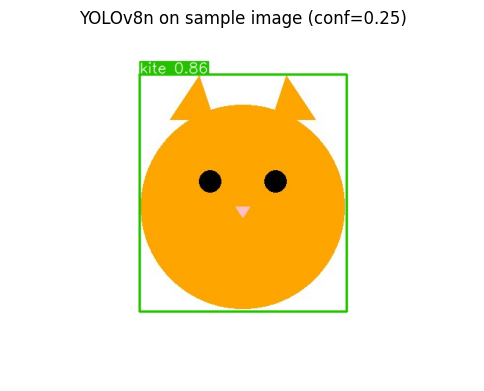

In [3]:
# Visualize with default conf=0.25
r = model.predict(source=img_path, imgsz=640, conf=0.25, verbose=False)[0]
annotated = r.plot()
plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('YOLOv8n on sample image (conf=0.25)')
plt.show()

## 2. Resolution sweep: 320 vs 416 vs 640

Speed scales roughly with H × W. Detail scales with resolution. Pick the smallest size that meets your recall on the smallest object of interest.

In [4]:
# Warm-up
_ = model.predict(source=img_path, imgsz=640, verbose=False)

for imgsz in [320, 416, 640]:
    times = []
    for _ in range(20):
        t0 = time.perf_counter()
        _ = model.predict(source=img_path, imgsz=imgsz, conf=0.25, verbose=False)
        times.append((time.perf_counter() - t0) * 1000.0)
    arr = np.array(times)
    print(f'imgsz={imgsz:>4d}  mean={arr.mean():6.2f} ms  P95={np.percentile(arr, 95):6.2f} ms  fps={1000/arr.mean():5.1f}')

imgsz= 320  mean= 13.08 ms  P95= 14.20 ms  fps= 76.5


imgsz= 416  mean= 18.57 ms  P95= 27.24 ms  fps= 53.9


imgsz= 640  mean= 31.31 ms  P95= 34.47 ms  fps= 31.9


## 3. End-to-end FPS on the sample video

This is the operationally meaningful number — capture + inference + postprocess + plot.

In [5]:
cap = cv2.VideoCapture('../datasets/sample_video.mp4')
n = 0; start = time.perf_counter()
while True:
    ok, frame = cap.read()
    if not ok:
        break
    _ = model.predict(source=frame, imgsz=640, conf=0.25, verbose=False)
    n += 1
    if n >= 60:
        break
elapsed = time.perf_counter() - start
cap.release()
print(f'processed {n} frames in {elapsed:.2f} s  →  {n/elapsed:.1f} FPS end-to-end')

processed 60 frames in 2.04 s  →  29.5 FPS end-to-end


## 4. Export to ONNX

Same model file works in ONNX Runtime / TensorRT (via `trtexec`) / OpenVINO.

In [6]:
onnx_path = model.export(format='onnx', imgsz=640, opset=17, simplify=True)
print('wrote', onnx_path, f'({Path(onnx_path).stat().st_size / 1024 / 1024:.2f} MB)')

Ultralytics 8.4.54 🚀 Python-3.11.15 torch-2.12.0+cu130 CPU (11th Gen Intel Core i7-11800H @ 2.30GHz)


💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/



PyTorch: starting from '../projects/project_02_yolo_realtime_camera/yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)


requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [onnxslim]




...


ONNX: starting export with onnx 1.21.0 opset 17...


ONNX: slimming with onnxslim 0.1.94...


ONNX: export success ✅ 2.2s, saved as '../projects/project_02_yolo_realtime_camera/yolov8n.onnx' (12.3 MB)



Export complete (2.3s)
Results saved to /home/bangbc/Documents/AI_Courses/Edge_Physical_AI/projects/project_02_yolo_realtime_camera/yolov8n.onnx
Predict:         yolo predict task=detect model=../projects/project_02_yolo_realtime_camera/yolov8n.onnx imgsz=640 
Validate:        yolo val task=detect model=../projects/project_02_yolo_realtime_camera/yolov8n.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


wrote ../projects/project_02_yolo_realtime_camera/yolov8n.onnx (12.26 MB)


## Take-aways

1. YOLOv8n is the right starting point for almost any edge detection task.
2. `conf` and `iou` thresholds change *how many* detections you keep; they do not change the model.
3. Cutting imgsz from 640 to 320 typically gives 3-4× speedup at the cost of small-object recall.
4. End-to-end FPS is always lower than single-image-only latency reports.
5. Export to ONNX makes the same model deployable everywhere — Pi (TFLite), Jetson (TensorRT), Intel (OpenVINO).